In [1]:
import pandas as pd
from pathlib import Path

def load_processed_tables(
    out_dir: str | Path,
    prefix: str = "tx_shoreline",
    format: str = "parquet",
):
    out_dir = Path(out_dir)

    if format == "parquet":
        shoreline_df = pd.read_parquet(out_dir / f"{prefix}_obs.parquet")
        transects = pd.read_parquet(out_dir / f"{prefix}_transects.parquet")
        stats = pd.read_parquet(out_dir / f"{prefix}_stats.parquet")
    elif format == "csv":
        shoreline_df = pd.read_csv(out_dir / f"{prefix}_obs.csv", parse_dates=["datetime"])
        transects = pd.read_csv(out_dir / f"{prefix}_transects.csv")
        stats = pd.read_csv(out_dir / f"{prefix}_stats.csv")
    else:
        raise ValueError("format must be 'parquet' or 'csv'")

    return shoreline_df, transects, stats

df_loess, transects, stats = load_processed_tables(
    "F:/crs/proj/2026_shoreline_analysis/processed",
    prefix="tx_shoreline",
    format="parquet",
)

Global median shoreline position (m): 52.329716
Variance fractions relative to total:
monthly - longterm : 0.020955323522281678
seasonal - longterm: 0.013135237756912187
longterm           : 1.1702333659054307


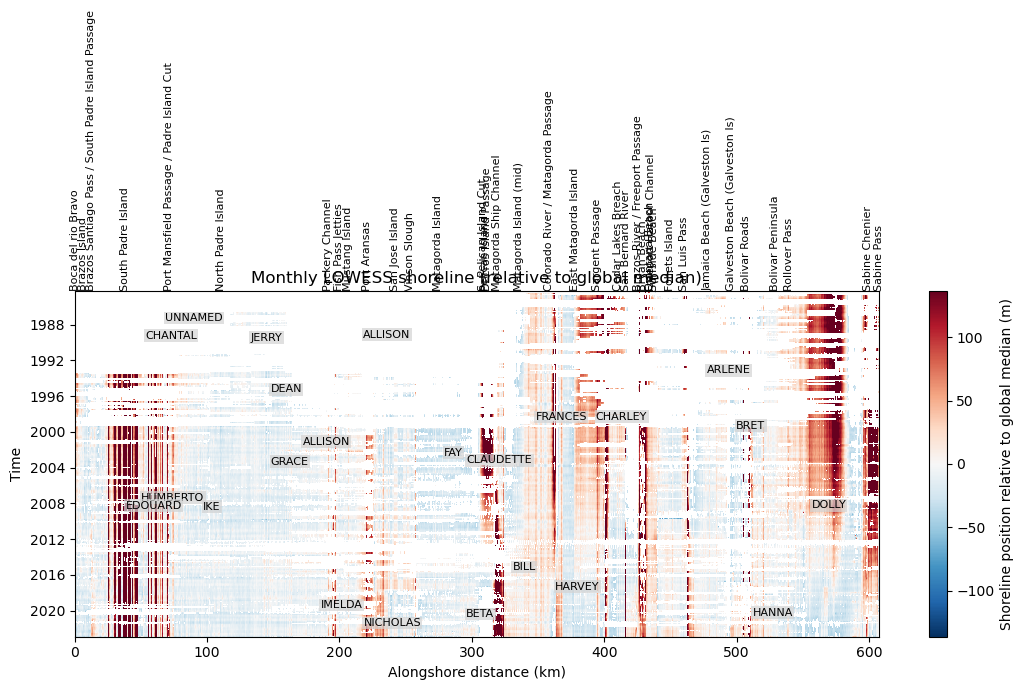

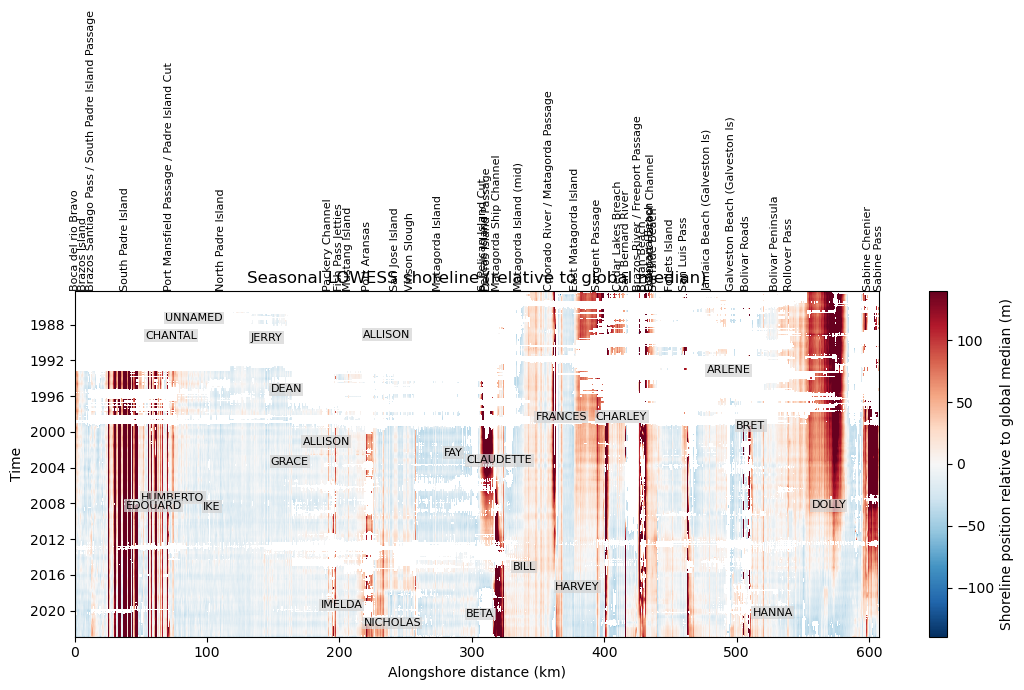

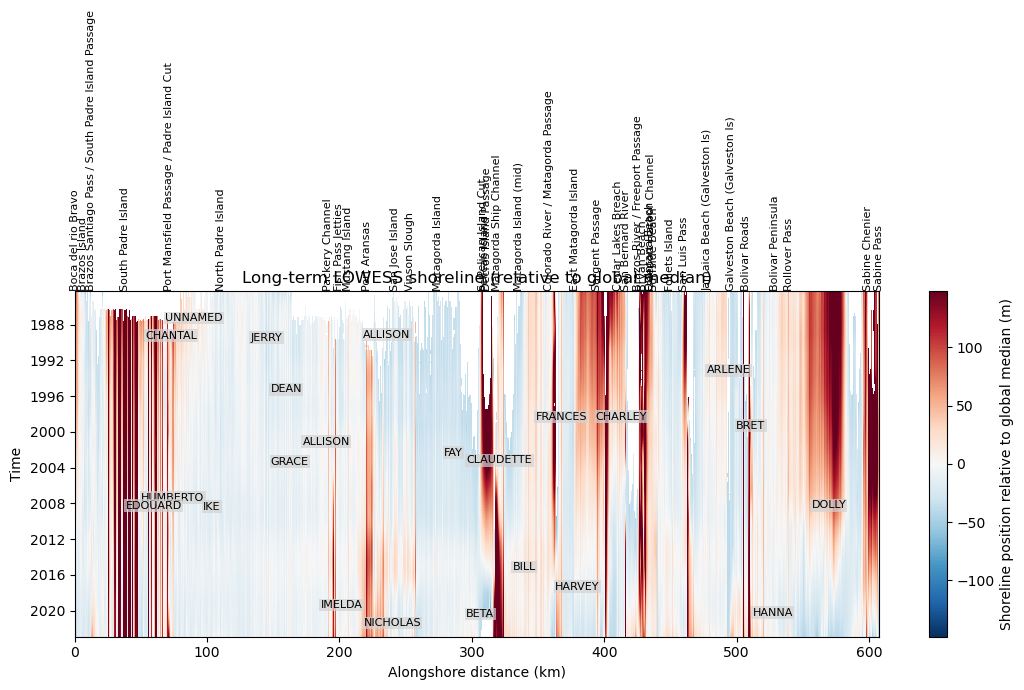

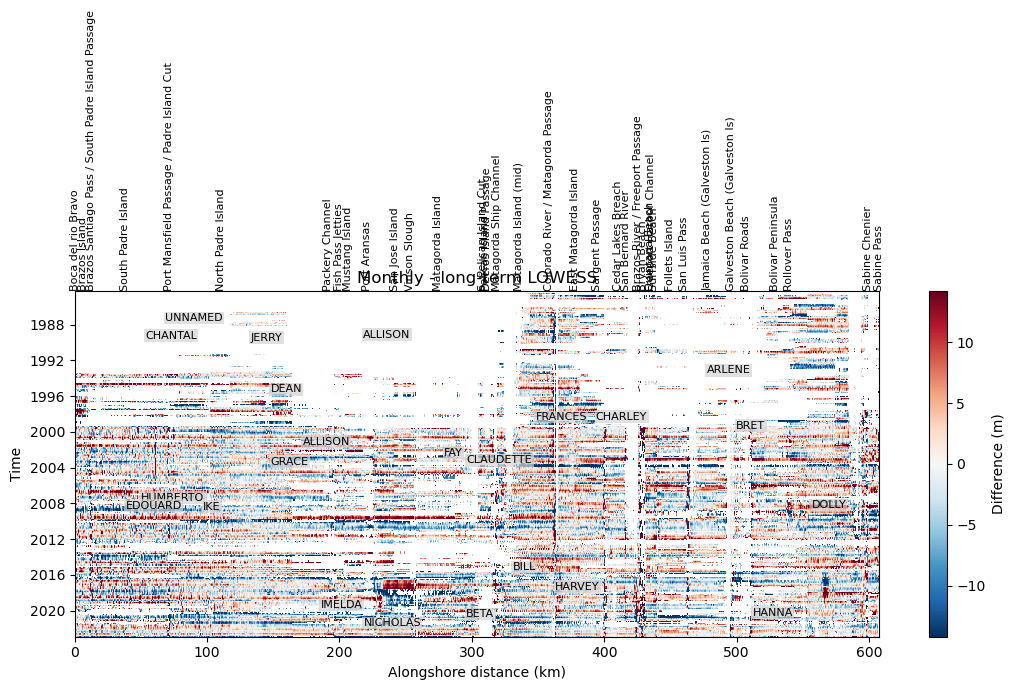

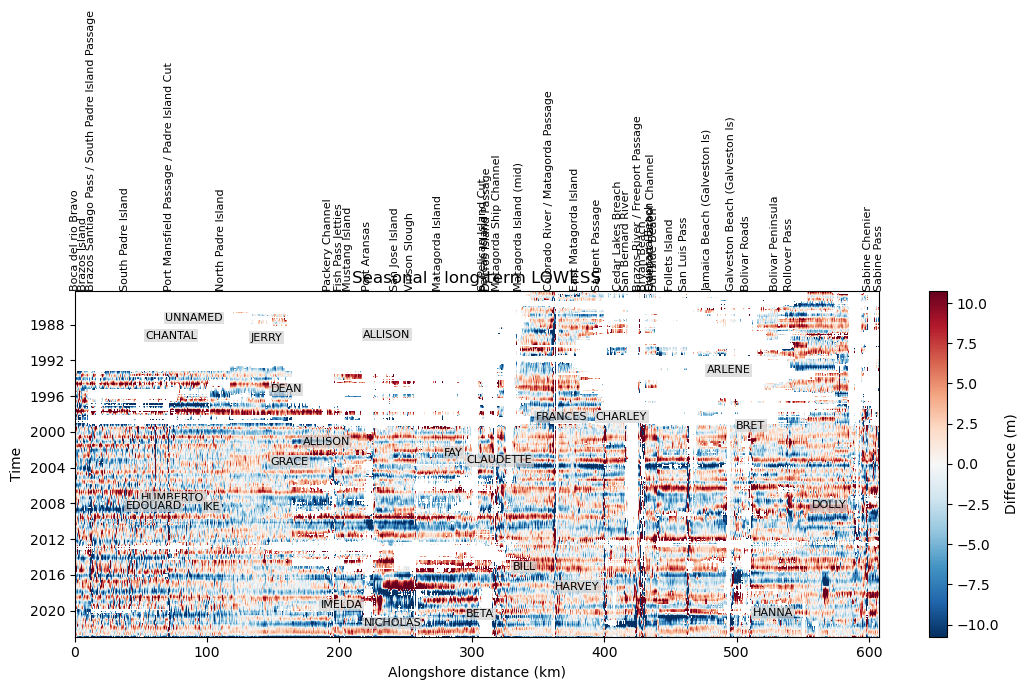

Saved outputs to: F:\crs\proj\2026_shoreline_analysis\loess_monthly_basis
Saved sample plots to: F:\crs\proj\2026_shoreline_analysis\loess_monthly_basis\sample_profiles


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ============================================================
# USER SETTINGS
# ============================================================
OUT_DIR = Path("F:/crs/proj/2026_shoreline_analysis/loess_monthly_basis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PLACE_FILE = "F:/crs/proj/2026_shoreline_analysis/place_names.csv"
STORM_FILE = "F:/crs/proj/2026_shoreline_analysis/hurricanes.csv"

# monthly grid for ALL smoothers
FREQ = "MS"

# windows in days, all evaluated on same monthly grid
WINDOW_MONTHLY  =  90    # short
WINDOW_SEASONAL = 180    # intermediate
WINDOW_LONGTERM = 4*365    # long-term; try 540 later if you want smoother background

MINPTS_MONTHLY  = 5
MINPTS_SEASONAL = 8
MINPTS_LONGTERM = 12

NSAMPLE_PLOTS = 20
RANDOM_STATE = 42

# ============================================================
# CORE LOWESS
# ============================================================
def loess_time_grid(t_days, y, tgrid_days, window_days=90, min_points=5):
    t = np.asarray(t_days, float)
    y = np.asarray(y, float)
    tg = np.asarray(tgrid_days, float)

    yhat = np.full_like(tg, np.nan, float)
    npts = np.zeros_like(tg, int)

    for j, t0 in enumerate(tg):
        dt = np.abs(t - t0)
        mask = np.isfinite(dt) & np.isfinite(y) & (dt <= window_days)

        if np.sum(mask) < min_points:
            continue

        tj = t[mask]
        yj = y[mask]

        w = (1 - (dt[mask] / window_days)**3)**3

        X = np.vstack([np.ones_like(tj), tj - t0]).T
        WX = X * w[:, None]
        beta = np.linalg.pinv(X.T @ WX) @ (X.T @ (w * yj))

        yhat[j] = beta[0]
        npts[j] = np.sum(mask)

    return yhat, npts


# ============================================================
# BUILD ONE MONTHLY GRID FOR ALL TRANSECTS
# ============================================================
def build_loess_monthly_grid(df, freq="MS",
                             window_days=90, min_points=5,
                             reverse_s=True):
    g = df.copy()
    g["datetime"] = pd.to_datetime(g["datetime"], errors="coerce")
    g["distance"] = pd.to_numeric(g["distance"], errors="coerce")
    g["s_km"] = pd.to_numeric(g["s_km"], errors="coerce")
    g["ID"] = g["ID"].astype(str)

    g = g.dropna(subset=["datetime", "distance", "s_km", "ID"]).copy()

    t0 = g["datetime"].min()
    tgrid = pd.date_range(g["datetime"].min(), g["datetime"].max(), freq=freq)
    tgrid_days = (tgrid - t0).total_seconds() / 86400.0

    # one row per transect, sorted by current s_km
    meta = (
        g.groupby("ID", as_index=False)
         .first()[["ID", "s_km", "shoreline_x", "shoreline_y"]]
         .sort_values("s_km")
         .reset_index(drop=True)
    )

    # reverse direction so new alongshore starts at last transect
    if reverse_s:
        meta = meta.iloc[::-1].reset_index(drop=True)
        s_old = meta["s_km"].to_numpy(float)
        s_new = s_old[0] - s_old
        s_new = np.abs(s_new)
        meta["s_km_rev"] = s_new
        meta = meta.sort_values("s_km_rev").reset_index(drop=True)
        s = meta["s_km_rev"].to_numpy(float)
    else:
        meta["s_km_rev"] = meta["s_km"].to_numpy(float)
        s = meta["s_km_rev"].to_numpy(float)

    ids = meta["ID"].to_numpy()

    M = np.full((len(tgrid), len(ids)), np.nan)
    N = np.zeros((len(tgrid), len(ids)), dtype=int)

    tdays_all = (g["datetime"] - t0).dt.total_seconds() / 86400.0

    for j, tid in enumerate(ids):
        gt = g[g["ID"] == tid]
        yhat, npts = loess_time_grid(
            tdays_all.loc[gt.index].to_numpy(),
            gt["distance"].to_numpy(),
            tgrid_days.to_numpy(),
            window_days=window_days,
            min_points=min_points
        )
        M[:, j] = yhat
        N[:, j] = npts

    return tgrid, s, M, N, meta


# ============================================================
# HEATMAP PLOT
# ============================================================
def plot_heatmap(tgrid, s, M, title,
                 global_median,
                 places=None, storms=None,
                 cmap="RdBu_r",
                 vlim=None,
                 cbar_label="Shoreline position relative to global median (m)"):
    fig, ax = plt.subplots(figsize=(11, 7))

    Mrel = M - global_median

    if vlim is None:
        vlim = np.nanpercentile(np.abs(Mrel), 95)

    ynum = mdates.date2num(pd.to_datetime(tgrid).to_pydatetime())

    im = ax.imshow(
        Mrel,
        aspect="auto",
        interpolation="none",
        extent=[s.min(), s.max(), ynum[-1], ynum[0]],
        cmap=cmap,
        vmin=-vlim,
        vmax= vlim,
    )

    ax.set_xlabel("Alongshore distance (km)")
    ax.set_ylabel("Time")
    ax.set_title(title)
    ax.yaxis_date()

    if places is not None:
        for _, r in places.iterrows():
            ax.text(r["s_km_rev"], ynum[0], r["Place_name"],
                    rotation=90, va="bottom", ha="center", fontsize=8)

    if storms is not None:
        for _, r in storms.iterrows():
            ax.text(r["s_km_rev"], mdates.date2num(r["landfall_time"]), r["storm_name"],
                    fontsize=8,
                    bbox=dict(facecolor="lightgray", edgecolor="none", alpha=0.7, pad=1))

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    fig.tight_layout()
    return fig, ax


# ============================================================
# LONG FORMAT TABLE FROM MATRICES
# ============================================================
def matrices_to_long_table(tgrid, meta,
                           M_monthly, N_monthly,
                           M_seasonal, N_seasonal,
                           M_longterm, N_longterm):
    nt = len(tgrid)
    nx = len(meta)

    tt = np.repeat(pd.to_datetime(tgrid).values, nx)
    ii = np.tile(np.arange(nx), nt)

    out = pd.DataFrame({
        "datetime": tt,
        "ID": meta["ID"].to_numpy()[ii],
        "s_km_rev": meta["s_km_rev"].to_numpy()[ii],
        "shoreline_x": meta["shoreline_x"].to_numpy()[ii],
        "shoreline_y": meta["shoreline_y"].to_numpy()[ii],
        "monthly": M_monthly.reshape(-1),
        "n_monthly": N_monthly.reshape(-1),
        "seasonal": M_seasonal.reshape(-1),
        "n_seasonal": N_seasonal.reshape(-1),
        "longterm": M_longterm.reshape(-1),
        "n_longterm": N_longterm.reshape(-1),
    })

    out["monthly_minus_longterm"] = out["monthly"] - out["longterm"]
    out["seasonal_minus_longterm"] = out["seasonal"] - out["longterm"]
    out["monthly_minus_seasonal"] = out["monthly"] - out["seasonal"]

    return out


# ============================================================
# LOAD PLACE NAMES / HURRICANES AND MAP TO REVERSED S
# ============================================================
places = pd.read_csv(PLACE_FILE)
storms = pd.read_csv(STORM_FILE)
storms["landfall_time"] = pd.to_datetime(storms["landfall_time"], errors="coerce", utc=True).dt.tz_convert(None)

# nearest-transect mapping for place names
tran0 = (
    df_loess.groupby("ID", as_index=False)
           .first()[["ID", "shoreline_x", "shoreline_y", "s_km"]]
           .copy()
)

xy = tran0[["shoreline_x", "shoreline_y"]].to_numpy()
from scipy.spatial import cKDTree
tree = cKDTree(xy)

pts = places[["Longitude", "Latitude"]].to_numpy()
_, idx = tree.query(pts)

places["ID"] = tran0["ID"].to_numpy()[idx]
places["s_km"] = tran0["s_km"].to_numpy()[idx]

# reversed alongshore mapping based on current global s_km
smax = np.nanmax(tran0["s_km"].to_numpy(float))
places["s_km_rev"] = smax - places["s_km"]
storms["s_km_rev"] = smax - pd.to_numeric(storms["s_km"], errors="coerce")


# ============================================================
# BUILD THE THREE MONTHLY-BASIS SMOOTHERS
# ============================================================
tgrid, s_rev, M_monthly,  N_monthly,  meta = build_loess_monthly_grid(
    df_loess, freq=FREQ,
    window_days=WINDOW_MONTHLY, min_points=MINPTS_MONTHLY,
    reverse_s=True
)

_, _, M_seasonal, N_seasonal, _ = build_loess_monthly_grid(
    df_loess, freq=FREQ,
    window_days=WINDOW_SEASONAL, min_points=MINPTS_SEASONAL,
    reverse_s=True
)

_, _, M_longterm, N_longterm, _ = build_loess_monthly_grid(
    df_loess, freq=FREQ,
    window_days=WINDOW_LONGTERM, min_points=MINPTS_LONGTERM,
    reverse_s=True
)

# update place and storm positions to match exact reversed direction in meta
id_to_srev = dict(zip(meta["ID"], meta["s_km_rev"]))
places["s_km_rev"] = places["ID"].map(id_to_srev)
storms["s_km_rev"] = storms["s_km_rev"]  # already reversed from original s_km

# ============================================================
# GLOBAL MEDIAN REFERENCE
# ============================================================
global_median = np.nanmedian(pd.to_numeric(df_loess["distance"], errors="coerce"))
print("Global median shoreline position (m):", global_median)

# optional variance fractions on common monthly basis
var_total = np.nanvar((M_monthly - global_median).reshape(-1))
var_monthly_long = np.nanvar((M_monthly - M_longterm).reshape(-1))
var_seasonal_long = np.nanvar((M_seasonal - M_longterm).reshape(-1))
var_long = np.nanvar((M_longterm - global_median).reshape(-1))

print("Variance fractions relative to total:")
print("monthly - longterm :", var_monthly_long / var_total)
print("seasonal - longterm:", var_seasonal_long / var_total)
print("longterm           :", var_long / var_total)

# ============================================================
# SAVE MATRICES AND METADATA
# ============================================================
np.savez_compressed(
    OUT_DIR / "loess_monthly_basis_grids.npz",
    tgrid=tgrid.values.astype("datetime64[ns]"),
    s_km_rev=s_rev,
    ID=meta["ID"].to_numpy().astype(str),
    M_monthly=M_monthly,
    N_monthly=N_monthly,
    M_seasonal=M_seasonal,
    N_seasonal=N_seasonal,
    M_longterm=M_longterm,
    N_longterm=N_longterm,
    global_median=global_median,
)

meta.to_csv(OUT_DIR / "loess_monthly_basis_meta.csv", index=False)

df_grid_long = matrices_to_long_table(
    tgrid, meta,
    M_monthly, N_monthly,
    M_seasonal, N_seasonal,
    M_longterm, N_longterm
)
df_grid_long.to_parquet(OUT_DIR / "loess_monthly_basis_long.parquet", index=False)
df_grid_long.to_csv(OUT_DIR / "loess_monthly_basis_long.csv", index=False)

# also save matrix-style parquet tables for quick inspection
pd.DataFrame(M_monthly,  index=tgrid, columns=meta["ID"]).to_parquet(OUT_DIR / "M_monthly.parquet")
pd.DataFrame(M_seasonal, index=tgrid, columns=meta["ID"]).to_parquet(OUT_DIR / "M_seasonal.parquet")
pd.DataFrame(M_longterm, index=tgrid, columns=meta["ID"]).to_parquet(OUT_DIR / "M_longterm.parquet")

# ============================================================
# HEATMAPS RELATIVE TO GLOBAL MEDIAN
# ============================================================
v_monthly = np.nanpercentile(np.abs(M_monthly  - global_median), 95)
v_seasonal = np.nanpercentile(np.abs(M_seasonal - global_median), 95)
v_longterm = np.nanpercentile(np.abs(M_longterm - global_median), 95)

fig1, ax1 = plot_heatmap(
    tgrid, s_rev, M_monthly,
    "Monthly LOWESS shoreline (relative to global median)",
    global_median=global_median,
    places=places, storms=storms, vlim=v_monthly
)
fig1.savefig(OUT_DIR / "heatmap_monthly.png", dpi=200, bbox_inches="tight")

fig2, ax2 = plot_heatmap(
    tgrid, s_rev, M_seasonal,
    "Seasonal LOWESS shoreline (relative to global median)",
    global_median=global_median,
    places=places, storms=storms, vlim=v_seasonal
)
fig2.savefig(OUT_DIR / "heatmap_seasonal.png", dpi=200, bbox_inches="tight")

fig3, ax3 = plot_heatmap(
    tgrid, s_rev, M_longterm,
    "Long-term LOWESS shoreline (relative to global median)",
    global_median=global_median,
    places=places, storms=storms, vlim=v_longterm
)
fig3.savefig(OUT_DIR / "heatmap_longterm.png", dpi=200, bbox_inches="tight")

# optional difference heatmaps on same monthly basis
fig4, ax4 = plot_heatmap(
    tgrid, s_rev, M_monthly - M_longterm + global_median,
    "Monthly - long-term LOWESS",
    global_median=global_median,
    places=places, storms=storms,
    vlim=np.nanpercentile(np.abs((M_monthly - M_longterm).reshape(-1)), 95),
    cbar_label="Difference (m)"
)
fig4.savefig(OUT_DIR / "heatmap_monthly_minus_longterm.png", dpi=200, bbox_inches="tight")

fig5, ax5 = plot_heatmap(
    tgrid, s_rev, M_seasonal - M_longterm + global_median,
    "Seasonal - long-term LOWESS",
    global_median=global_median,
    places=places, storms=storms,
    vlim=np.nanpercentile(np.abs((M_seasonal - M_longterm).reshape(-1)), 95),
    cbar_label="Difference (m)"
)
fig5.savefig(OUT_DIR / "heatmap_seasonal_minus_longterm.png", dpi=200, bbox_inches="tight")

plt.show()

# ============================================================
# SAMPLE PLOTS
# ============================================================
rng = np.random.default_rng(RANDOM_STATE)
ids_all = meta["ID"].to_numpy()
nplot = min(NSAMPLE_PLOTS, len(ids_all))
sample_ids = pd.Series(ids_all).sample(n=nplot, random_state=RANDOM_STATE).to_numpy()

sample_dir = OUT_DIR / "sample_profiles"
sample_dir.mkdir(parents=True, exist_ok=True)

id_to_col = {tid: j for j, tid in enumerate(meta["ID"].to_numpy())}

for tid in sample_ids:
    g = df_loess[df_loess["ID"] == tid].copy().sort_values("datetime")
    g["datetime"] = pd.to_datetime(g["datetime"], errors="coerce")
    g["distance"] = pd.to_numeric(g["distance"], errors="coerce")

    j = id_to_col[tid]
    s_this = meta.loc[meta["ID"] == tid, "s_km_rev"].iloc[0]

    fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

    axs[0].plot(g["datetime"], g["distance"], ".", alpha=0.35, label="raw")
    axs[0].plot(tgrid, M_monthly[:, j], "-", lw=2, label="monthly")
    axs[0].plot(tgrid, M_seasonal[:, j], "-", lw=2, label="seasonal")
    axs[0].plot(tgrid, M_longterm[:, j], "-", lw=2.5, label="longterm")
    axs[0].axhline(global_median, ls="--", lw=1, color="0.5")
    axs[0].set_ylabel("Position (m)")
    axs[0].set_title(f"{tid}   s = {s_this:.1f} km")
    axs[0].legend()

    axs[1].plot(tgrid, M_monthly[:, j] - M_longterm[:, j], "-", lw=2)
    axs[1].axhline(0, ls="--", lw=1, color="0.5")
    axs[1].set_ylabel("Monthly-\nLong (m)")

    axs[2].plot(tgrid, M_seasonal[:, j] - M_longterm[:, j], "-", lw=2)
    axs[2].axhline(0, ls="--", lw=1, color="0.5")
    axs[2].set_ylabel("Seasonal-\nLong (m)")

    axs[3].plot(tgrid, M_monthly[:, j] - global_median, "-", lw=2, label="monthly-med")
    axs[3].plot(tgrid, M_seasonal[:, j] - global_median, "-", lw=2, label="seasonal-med")
    axs[3].plot(tgrid, M_longterm[:, j] - global_median, "-", lw=2.5, label="long-med")
    axs[3].axhline(0, ls="--", lw=1, color="0.5")
    axs[3].set_ylabel("Relative to\nmedian (m)")
    axs[3].set_xlabel("Time")
    axs[3].legend()

    fig.tight_layout()
    fig.savefig(sample_dir / f"{tid}_monthly_basis_loess.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

print("Saved outputs to:", OUT_DIR)
print("Saved sample plots to:", sample_dir)

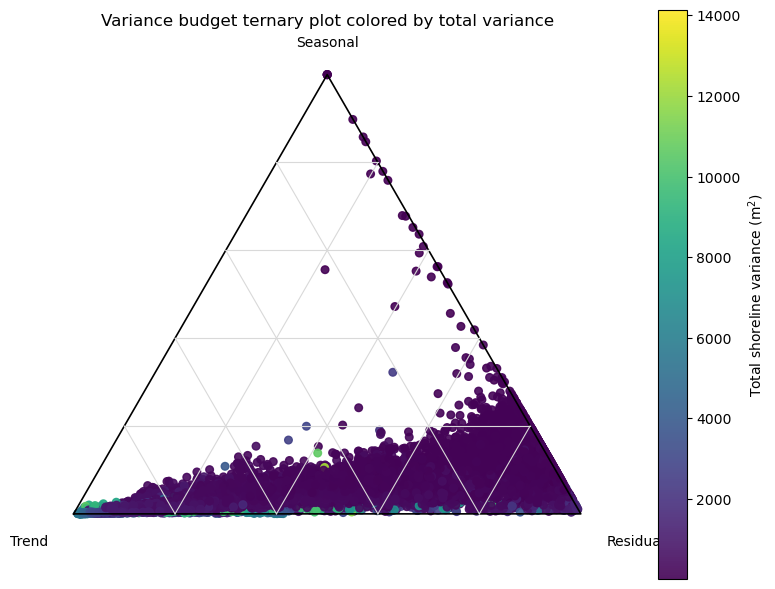

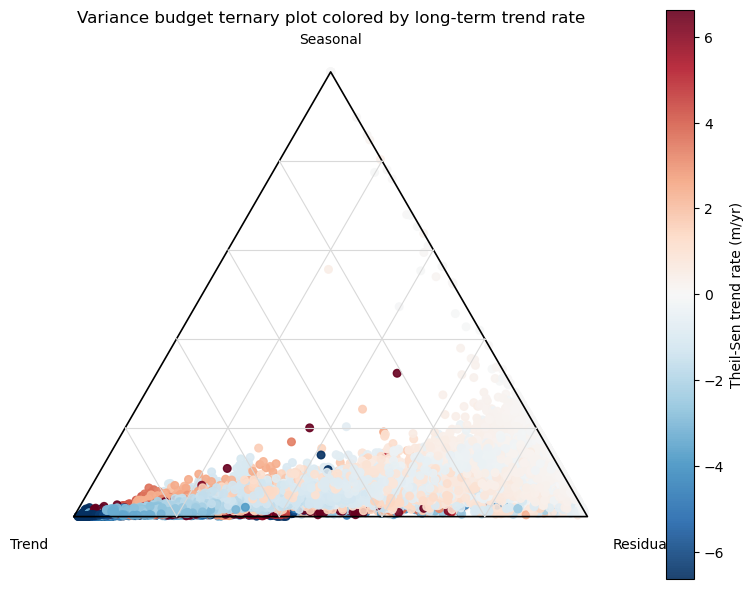

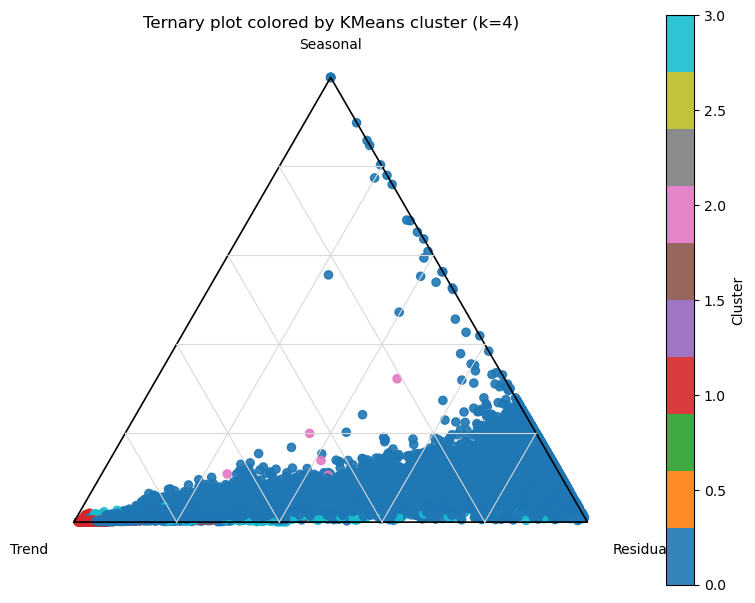

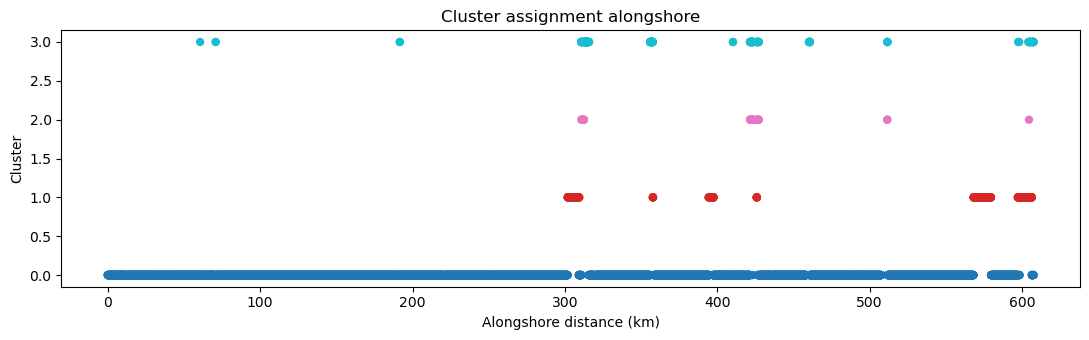

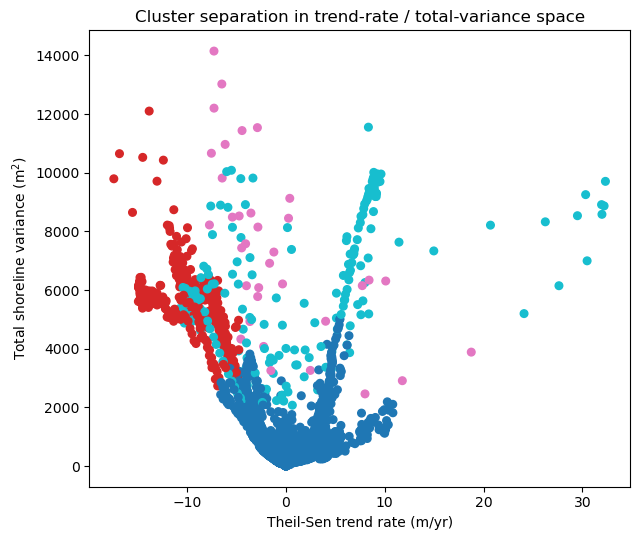

Saved variance-budget outputs to: F:\crs\proj\2026_shoreline_analysis\loess_monthly_basis

Cluster summary:
         var_trend  var_seasonal  var_resid  var_total_raw  rate_ts  \
cluster                                                               
0.0        226.340         8.801     96.338        453.180   -0.102   
1.0       4929.856        14.962    280.073       5353.432   -8.992   
2.0       1386.941       469.183   3852.530       7420.207   -0.976   
3.0       3663.749        84.043   3045.872       6077.446    1.513   

         pct_trend  pct_seasonal  pct_resid  
cluster                                      
0.0         41.288         7.053     51.659  
1.0         94.606         0.291      5.103  
2.0         23.862         9.305     66.833  
3.0         47.606         1.815     50.578  


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ============================================================
# SETTINGS
# ============================================================
if "OUT_DIR" not in globals():
    OUT_DIR = Path("F:/crs/proj/2026_shoreline_analysis/loess_monthly_basis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

N_CLUSTERS = 4
RANDOM_STATE = 42

# ============================================================
# HELPERS
# ============================================================
def decimal_year(dt):
    dt = pd.to_datetime(dt)
    year = dt.dt.year
    doy = dt.dt.dayofyear
    return year + (doy - 1) / 365.25

def ternary_xy(a, b, c):
    """
    Map ternary fractions (a,b,c), summing to 1, to Cartesian coords.
    Vertices:
        a -> left
        b -> right
        c -> top
    """
    x = b + 0.5 * c
    y = (np.sqrt(3) / 2.0) * c
    return x, y

def draw_ternary_axes(ax, labels=("Trend", "Residual", "Seasonal")):
    h = np.sqrt(3) / 2.0
    tri = np.array([[0, 0], [1, 0], [0.5, h], [0, 0]])
    ax.plot(tri[:, 0], tri[:, 1], "k-", lw=1.2)

    # light grid lines at 0.2 intervals
    vals = np.arange(0.2, 1.0, 0.2)
    for v in vals:
        # constant a
        x1, y1 = ternary_xy(v, 0, 1 - v)
        x2, y2 = ternary_xy(v, 1 - v, 0)
        ax.plot([x1, x2], [y1, y2], color="0.85", lw=0.8)

        # constant b
        x1, y1 = ternary_xy(0, v, 1 - v)
        x2, y2 = ternary_xy(1 - v, v, 0)
        ax.plot([x1, x2], [y1, y2], color="0.85", lw=0.8)

        # constant c
        x1, y1 = ternary_xy(0, 1 - v, v)
        x2, y2 = ternary_xy(1 - v, 0, v)
        ax.plot([x1, x2], [y1, y2], color="0.85", lw=0.8)

    ax.text(-0.05, -0.04, labels[0], ha="right", va="top")
    ax.text(1.05, -0.04, labels[1], ha="left", va="top")
    ax.text(0.5, h + 0.05, labels[2], ha="center", va="bottom")

    ax.set_xlim(-0.08, 1.08)
    ax.set_ylim(-0.08, h + 0.08)
    ax.set_aspect("equal")
    ax.axis("off")

# ============================================================
# PREP MONTHLY GRID TABLE
# ============================================================
g = df_grid_long.copy()
g["datetime"] = pd.to_datetime(g["datetime"], errors="coerce")
for col in ["monthly", "seasonal", "longterm", "s_km_rev"]:
    g[col] = pd.to_numeric(g[col], errors="coerce")

g = g.dropna(subset=["datetime", "ID", "monthly"]).copy()
g["t_dec"] = decimal_year(g["datetime"])

# stats table must contain Theil-Sen slope; intercept_ts preferred but optional
st = stats.copy()
st["ID"] = st["ID"].astype(str)

have_intercept_ts = "intercept_ts" in st.columns
have_total_var_raw = "variance" in st.columns

# ============================================================
# BUILD TRANSECT VARIANCE BUDGETS
# ============================================================
rows = []

for tid, gt in g.groupby("ID"):
    gt = gt.sort_values("datetime").copy()

    rate_ts = st.loc[st["ID"] == tid, "rate_ts"].iloc[0] if np.any(st["ID"] == tid) else np.nan
    intercept_ts = st.loc[st["ID"] == tid, "intercept_ts"].iloc[0] if (have_intercept_ts and np.any(st["ID"] == tid)) else np.nan

    if not np.isfinite(rate_ts):
        continue

    t = gt["t_dec"].to_numpy(float)
    x = gt["monthly"].to_numpy(float)

    if have_intercept_ts and np.isfinite(intercept_ts):
        trend = intercept_ts + rate_ts * t
    else:
        trend = np.nanmean(x) + rate_ts * (t - np.nanmean(t))

    detrended = x - trend

    # monthly climatology of detrended monthly-grid series
    month_num = gt["datetime"].dt.month.to_numpy()
    clim = pd.DataFrame({"month": month_num, "detrended": detrended}).groupby("month")["detrended"].mean()
    seasonal = np.array([clim.loc[m] for m in month_num], dtype=float)

    residual = x - trend - seasonal

    var_trend = np.nanvar(trend, ddof=1)
    var_seasonal = np.nanvar(seasonal, ddof=1)
    var_resid = np.nanvar(residual, ddof=1)
    var_total_grid = np.nanvar(x, ddof=1)

    if have_total_var_raw and np.any(st["ID"] == tid):
        var_total_raw = st.loc[st["ID"] == tid, "variance"].iloc[0]
    else:
        var_total_raw = var_total_grid

    denom = var_trend + var_seasonal + var_resid
    if np.isfinite(denom) and denom > 0:
        p_trend = 100.0 * var_trend / denom
        p_seasonal = 100.0 * var_seasonal / denom
        p_resid = 100.0 * var_resid / denom
    else:
        p_trend = np.nan
        p_seasonal = np.nan
        p_resid = np.nan

    rows.append({
        "ID": tid,
        "s_km_rev": gt["s_km_rev"].iloc[0],
        "rate_ts": rate_ts,
        "trend_direction": np.sign(rate_ts),   # -1 landward / +1 seaward if that matches your sign convention
        "var_trend": var_trend,
        "var_seasonal": var_seasonal,
        "var_resid": var_resid,
        "var_total_grid": var_total_grid,
        "var_total_raw": var_total_raw,
        "pct_trend": p_trend,
        "pct_seasonal": p_seasonal,
        "pct_resid": p_resid,
    })

budget = pd.DataFrame(rows)

# ============================================================
# TERNARY COORDS
# ============================================================
a = budget["pct_trend"].to_numpy(float) / 100.0
b = budget["pct_resid"].to_numpy(float) / 100.0
c = budget["pct_seasonal"].to_numpy(float) / 100.0

budget["tern_x"], budget["tern_y"] = ternary_xy(a, b, c)

# ============================================================
# TERNARY PLOT 1: COLOR BY TOTAL VARIANCE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))
draw_ternary_axes(ax, labels=("Trend", "Residual", "Seasonal"))

sc = ax.scatter(
    budget["tern_x"],
    budget["tern_y"],
    c=budget["var_total_raw"],
    s=30,
    cmap="viridis",
    alpha=0.9
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("Total shoreline variance (m$^2$)")
ax.set_title("Variance budget ternary plot colored by total variance")

fig.tight_layout()
fig.savefig(OUT_DIR / "ternary_total_variance.png", dpi=200, bbox_inches="tight")

# ============================================================
# TERNARY PLOT 2: COLOR BY THEIL-SEN TREND RATE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))
draw_ternary_axes(ax, labels=("Trend", "Residual", "Seasonal"))

v = np.nanpercentile(np.abs(budget["rate_ts"]), 95)

sc = ax.scatter(
    budget["tern_x"],
    budget["tern_y"],
    c=budget["rate_ts"],
    s=30,
    cmap="RdBu_r",
    vmin=-v,
    vmax=v,
    alpha=0.9
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("Theil-Sen trend rate (m/yr)")
ax.set_title("Variance budget ternary plot colored by long-term trend rate")

fig.tight_layout()
fig.savefig(OUT_DIR / "ternary_trend_rate.png", dpi=200, bbox_inches="tight")

# ============================================================
# CLUSTER ANALYSIS
# five features:
#   var_trend, var_seasonal, var_resid, total variance, rate_ts
# ============================================================
feat_cols = ["var_trend", "var_seasonal", "var_resid", "var_total_raw", "rate_ts"]
X = budget[feat_cols].to_numpy(float)

mask = np.all(np.isfinite(X), axis=1)
budget["cluster"] = np.nan

scaler = StandardScaler()
Xz = scaler.fit_transform(X[mask])

km = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
lab = km.fit_predict(Xz)

budget.loc[mask, "cluster"] = lab

# cluster summary
cluster_summary = (
    budget.groupby("cluster", dropna=True)[
        ["var_trend", "var_seasonal", "var_resid", "var_total_raw", "rate_ts",
         "pct_trend", "pct_seasonal", "pct_resid"]
    ]
    .mean()
    .sort_index()
)

# ============================================================
# CLUSTER PLOTS
# ============================================================
# ternary colored by cluster
fig, ax = plt.subplots(figsize=(8, 7))
draw_ternary_axes(ax, labels=("Trend", "Residual", "Seasonal"))

sc = ax.scatter(
    budget["tern_x"],
    budget["tern_y"],
    c=budget["cluster"],
    s=35,
    cmap="tab10",
    alpha=0.9
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("Cluster")
ax.set_title(f"Ternary plot colored by KMeans cluster (k={N_CLUSTERS})")

fig.tight_layout()
fig.savefig(OUT_DIR / "ternary_clusters.png", dpi=200, bbox_inches="tight")

# alongshore cluster plot
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.scatter(budget["s_km_rev"], budget["cluster"], c=budget["cluster"], cmap="tab10", s=25)
ax.set_xlabel("Alongshore distance (km)")
ax.set_ylabel("Cluster")
ax.set_title("Cluster assignment alongshore")
fig.tight_layout()
fig.savefig(OUT_DIR / "clusters_alongshore.png", dpi=200, bbox_inches="tight")

# optional: trend-rate vs total variance, colored by cluster
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(budget["rate_ts"], budget["var_total_raw"], c=budget["cluster"], cmap="tab10", s=30)
ax.set_xlabel("Theil-Sen trend rate (m/yr)")
ax.set_ylabel("Total shoreline variance (m$^2$)")
ax.set_title("Cluster separation in trend-rate / total-variance space")
fig.tight_layout()
fig.savefig(OUT_DIR / "clusters_rate_vs_variance.png", dpi=200, bbox_inches="tight")

plt.show()

# ============================================================
# SAVE TABLES
# ============================================================
budget.to_csv(OUT_DIR / "variance_budget_by_transect.csv", index=False)
budget.to_parquet(OUT_DIR / "variance_budget_by_transect.parquet", index=False)
cluster_summary.to_csv(OUT_DIR / "variance_budget_cluster_summary.csv")

print("Saved variance-budget outputs to:", OUT_DIR)
print()
print("Cluster summary:")
print(cluster_summary.round(3))

In [28]:
(budget["cluster"]==2).sum()/12126

np.float64(0.0028863598878443014)